# Multilayer Perceptron on Brainvita (From Scratch)

This notebook uses the custom `rice_ml.supervised_learning.MultilayerPerceptron` for binary classification of high-mobility Brainvita board states (`num_legal_moves >= 3`).

The MLP extends the perceptron by adding hidden layers and nonlinear activations. That extra capacity can model feature interactions, but it also makes the model less transparent. The notebook therefore compares against a perceptron baseline, watches the loss curve, and checks whether predicted probabilities separate the two classes.

## Learning Objectives

1. Explain how hidden layers and ReLU activations extend the perceptron.
2. Use train-only standardization for gradient-based neural-network training.
3. Compare MLP performance against a simpler linear perceptron baseline.
4. Evaluate train/test classification metrics and confusion matrices.
5. Interpret the loss curve and probability histogram as optimization and separation diagnostics.


## Dataset and Target

The MLP uses the same Brainvita classification setup as logistic regression and perceptron: class 1 means `num_legal_moves >= 3`, and class 0 means fewer than three legal moves.

This target asks whether the board state still has several immediate options. A neural network can model interactions among features such as mobility, clusters, adjacency, and reachability, but we still use the same curated feature set to avoid raw board encodings and move-coordinate leakage.

## 1. Mathematical Intuition

An MLP composes affine transforms and nonlinear activations:

$$
a^{(l)} = \phi\left(W^{(l)}a^{(l-1)} + b^{(l)}\right)
$$

This model uses:

- ReLU in hidden layers
- Sigmoid output for binary probability
- Binary cross-entropy objective
- Backpropagation with batch gradient descent


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root')


ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'
print('Repo root:', ROOT)
print('Dataset path:', DATA_PATH)

from rice_ml.supervised_learning import MultilayerPerceptron, Perceptron

Repo root: /Users/LakshSarda/Desktop/CMOR_438_Repository
Dataset path: /Users/LakshSarda/Desktop/CMOR_438_Repository/data/brainvita_dataset.csv


In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

raw_feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = raw_feature_cols + ['num_legal_moves']
selected_idx = [header.index(c) for c in selected_cols]
arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)

X_raw = arr[:, :-1]
y_reg = arr[:, -1]
y_bin = (y_reg >= 3.0).astype(int)

preferred_features = ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']
feature_cols = [c for c in preferred_features if c in raw_feature_cols]
keep_idx = [raw_feature_cols.index(c) for c in feature_cols]
X = X_raw[:, keep_idx]

print(f'Rows: {X.shape[0]:,} | Features: {X.shape[1]}')
print('Positive class rate (num_legal_moves >= 3):', float(y_bin.mean()))
print('Features used:', feature_cols)

y_target = y_bin

Rows: 238,486 | Features: 15
Positive class rate (num_legal_moves >= 3): 0.2917655543721644
Features used: ['peg_ratio', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'board_rows', 'board_cols']


## 2. Split and Scale

The MLP is trained with gradient descent, so feature scale matters. We split before scaling and compute `mu` and `sigma` only from the training set. This avoids leaking test-set information into the preprocessing pipeline.

In [3]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y_target[train_idx], y_target[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('Train samples:', X_train.shape[0], '| Test samples:', X_test.shape[0])


Train samples: 190788 | Test samples: 47698


## 3. Baseline and MLP Training

Before training the MLP, we fit a perceptron baseline on the same standardized data. This keeps the comparison honest: if the MLP performs better, the gain should come from hidden nonlinear layers rather than a different dataset or preprocessing pipeline.

The hidden layers `[16, 8]` are intentionally modest. The goal is to demonstrate nonlinear learning without turning the notebook into a black-box hyperparameter search.

In [4]:
def class_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    acc = float(np.mean(y_true == y_pred))
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1}

baseline = Perceptron(learning_rate=0.1, max_iter=200, fit_intercept=True, shuffle=True, random_state=42)
baseline.fit(X_train, y_train)
baseline_metrics = class_metrics(y_test, baseline.predict(X_test))

print('Perceptron baseline (test):', {k: round(v, 4) for k, v in baseline_metrics.items()})


Perceptron baseline (test): {'acc': 0.989, 'precision': 0.9883, 'recall': 0.9736, 'f1': 0.9809}


In [5]:
model = MultilayerPerceptron(hidden_layers=[16, 8], learning_rate=0.05, max_iter=600, tol=1e-7, random_state=42)
model.fit(X_train, y_train)

print('Hidden layers:', model.hidden_layers)
print('Iterations tracked in loss history:', len(model.loss_history_))
print('Final training loss:', model.loss_history_[-1])


Hidden layers: [16, 8]
Iterations tracked in loss history: 600
Final training loss: 0.03773436508920842


In [6]:
def classification_report_compact(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    acc = float(np.mean(y_true == y_pred))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    print('Classification summary')
    print('-' * 56)
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print('-' * 56)
    print('Confusion matrix [ [TN, FP], [FN, TP] ]')
    print(np.array([[tn, fp], [fn, tp]]))
    return acc, precision, recall, f1, (tn, fp, fn, tp)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('Train:')
classification_report_compact(y_train, y_pred_train)
print()
print('Test:')
classification_report_compact(y_test, y_pred_test)


Train:
Classification summary
--------------------------------------------------------
Accuracy : 0.9920
Precision: 0.9950
Recall   : 0.9776
F1-score : 0.9863
--------------------------------------------------------
Confusion matrix [ [TN, FP], [FN, TP] ]
[[134818    273]
 [  1245  54452]]

Test:
Classification summary
--------------------------------------------------------
Accuracy : 0.9916
Precision: 0.9949
Recall   : 0.9761
F1-score : 0.9854
--------------------------------------------------------
Confusion matrix [ [TN, FP], [FN, TP] ]
[[33743    70]
 [  332 13553]]


(0.991571973667659,
 0.9948616310651105,
 0.9760893050054015,
 0.9853860695070525,
 (33743, 70, 332, 13553))

## 4. Loss Curve and Probability Distribution

The loss curve checks optimization: binary cross-entropy should generally decrease as batch gradient descent updates the weights. The probability histogram checks separation: class-1 examples should concentrate near high predicted probabilities and class-0 examples near low probabilities.

These plots complement accuracy. They show whether the model is learning smoothly and whether its confidence distribution matches the class labels.

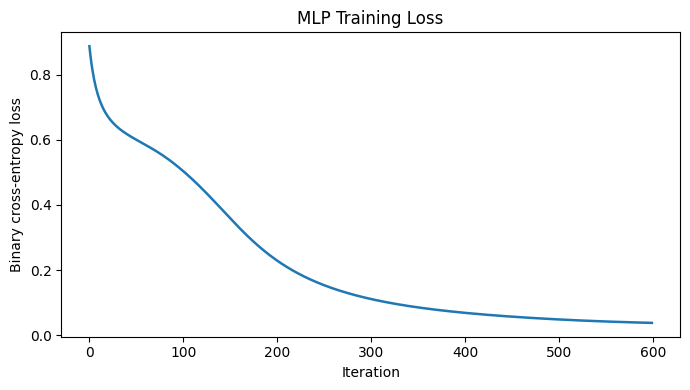

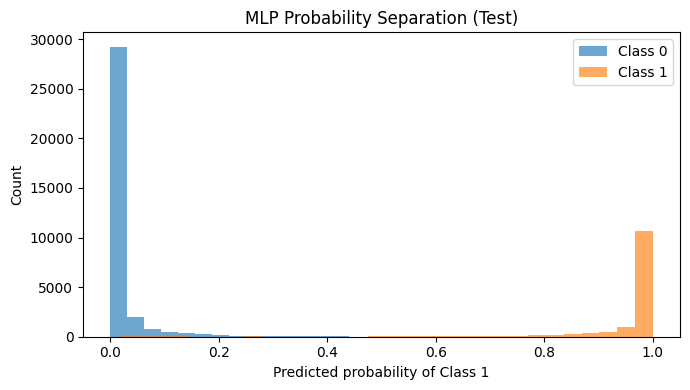

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(model.loss_history_, linewidth=1.8)
plt.title('MLP Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Binary cross-entropy loss')
plt.tight_layout()
plt.show()

probs = model.predict_proba(X_test)[:, 1]
plt.figure(figsize=(7, 4))
plt.hist(probs[y_test == 0], bins=30, alpha=0.65, label='Class 0')
plt.hist(probs[y_test == 1], bins=30, alpha=0.65, label='Class 1')
plt.xlabel('Predicted probability of Class 1')
plt.ylabel('Count')
plt.title('MLP Probability Separation (Test)')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Conclusion

The MLP is the highest-capacity classifier in this supervised set. It can learn nonlinear interactions among Brainvita features, which is why it is compared against the perceptron baseline rather than judged by accuracy alone.

What worked:

- The perceptron baseline gives a simple linear reference point.
- The MLP loss curve shows whether batch gradient descent is actually improving the objective.
- The probability histogram shows whether the network separates high- and low-mobility states.

What to watch:

- Higher capacity can overfit, so train/test metrics should stay close.
- MLP coefficients are not directly interpretable like linear or perceptron weights.
- If the MLP only barely beats the perceptron, the extra hidden layers may not be necessary for this feature set.
